In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')

from dataclasses import asdict
from src.models import ASSET_CONFIGS
from src.models import AssetType
from src.generator import generate_asset_register


In [ ]:
import pandas as pd
from dataclasses import asdict

assets = generate_asset_register()

df = pd.DataFrame([asdict(a) for a in assets])
df['asset_type'] = df['asset_type'].apply(lambda x: x.value)

# output the dataframe to a csv file
df.to_csv("../data/raw/asset_register.csv", index=False)

print(df.head())

  asset_id asset_type  install_year  age_years  age_ratio          zone  \
0  CE-0001    OH_Line          2007         19      0.475        Tuakau   
1  CE-0002    OH_Line          2004         22      0.550        Tuakau   
2  CE-0003    OH_Line          2009         17      0.425        Waiuku   
3  CE-0004    OH_Line          1998         28      0.700  Clarks_Beach   
4  CE-0005    OH_Line          2008         18      0.450        Pokeno   

   voltage_kv  customers_affected_if_fail  last_inspection_year  \
0          22                        1951                  2023   
1          11                        1854                  2024   
2          22                        1656                  2020   
3          11                         938                  2021   
4          22                         747                  2018   

   inspection_score  fault_count_5yr  is_critical_node  replacement_cost_nzd  
0                 7                2             False             

In [3]:
df = pd.read_csv('../data/raw/asset_register.csv')

Key found 1：How many assets are approaching 80% end-of-life (EOL) based on their age and design lifespan?

In [4]:
lifespan = {t.value: c.lifespan_years for t, c in ASSET_CONFIGS.items()}
df['design_lifespan'] = df['asset_type'].map(lifespan)
df['end_of_life_risk'] = df['age_ratio'] > 0.8
df['age_ratio_calc'] = df['age_years'] / df['design_lifespan']

eol = df[df['end_of_life_risk']].groupby('asset_type').size()
print("Number of assets exceeding 80% of their design life:")
print(eol)

Number of assets exceeding 80% of their design life:
asset_type
OH_Line        26
Substation      1
Switchgear     11
Transformer    25
UG_Cable        2
dtype: int64


Key found 2：Asset age


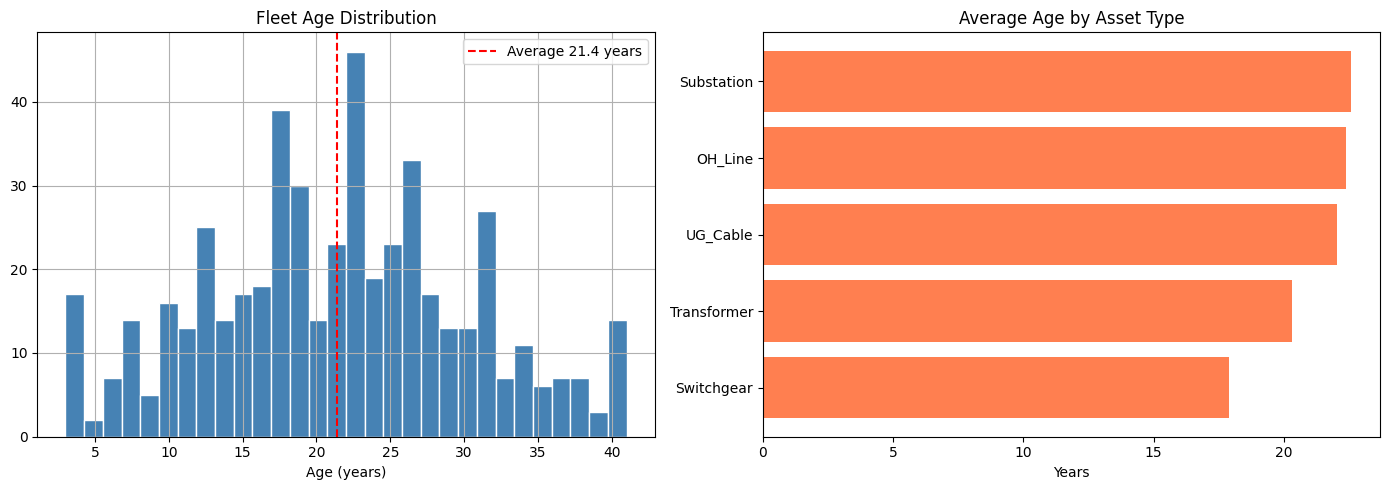

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['age_years'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df['age_years'].mean(), color='red', linestyle='--',
                label=f"Average {df['age_years'].mean():.1f} years")
axes[0].set_title('Fleet Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].legend()

avg_age = df.groupby('asset_type')['age_years'].mean().sort_values()
axes[1].barh(avg_age.index, avg_age.values, color='coral')
axes[1].set_title('Average Age by Asset Type')
axes[1].set_xlabel('Years')

plt.tight_layout()
plt.savefig('../output/eda_age.png', dpi=150)
plt.show()

Key found 3：inspection score vs fealure times


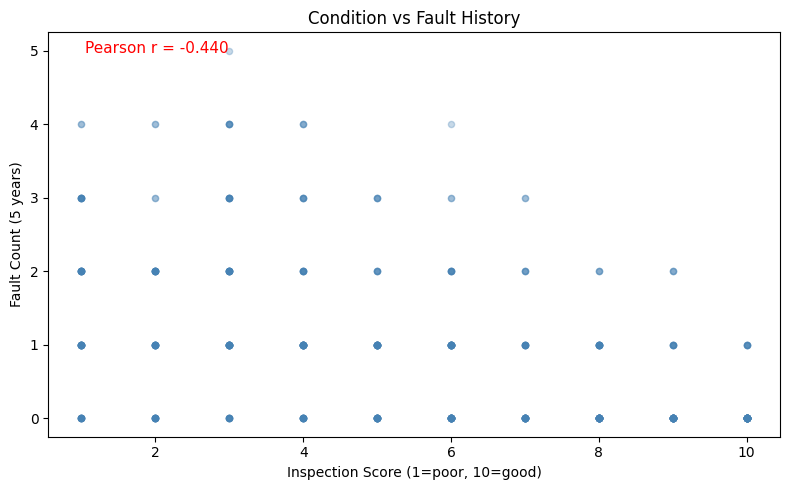


Correlation between inspection score and fault count: -0.440
(Negative correlation = lower scores associated with more faults, as expected)


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['inspection_score'], df['fault_count_5yr'],
           alpha=0.3, c='steelblue', s=20)
ax.set_xlabel('Inspection Score (1=poor, 10=good)')
ax.set_ylabel('Fault Count (5 years)')
ax.set_title('Condition vs Fault History')

corr = df['inspection_score'].corr(df['fault_count_5yr'])
ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}',
        transform=ax.transAxes, fontsize=11, color='red')
plt.tight_layout()
plt.savefig('../output/eda_condition_faults.png', dpi=150)
plt.show()

print(f"\nCorrelation between inspection score and fault count: {corr:.3f}")
print("(Negative correlation = lower scores associated with more faults, as expected)")